In [1]:
# Load the Kedro IPython extension
%load_ext kedro.ipython

[06/19/25 14:40:01] INFO     Using                                                                  ]8;id=44819;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=932490;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/framework/project/__init__.py#272\272]8;;\
                             '/Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/                
                             python3.11/site-packages/kedro/framework/project/rich_logging.yml' as                 
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=118828;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=444496;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=589895;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=518903;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as:                                              ]8;id=167980;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=631124;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             /Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model.                           
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/19/25 14:40:11] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=453033;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=724393;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro_telemetry/plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[06/19/25 14:40:13] INFO     Kedro project B2B Pricing Model                                        ]8;id=35665;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=32123;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=935096;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=169034;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

[06/19/25 14:40:14] INFO     Registered line magic 'run_viz'                                        ]8;id=455384;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=311738;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

In [70]:
df = catalog.load("master_trx_customer_tct").to_pandas()

[06/19/25 16:12:51] INFO     Loading data from master_trx_customer_tct                          ]8;id=764538;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=533940;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/io/data_catalog.py#403\403]8;;\
                             (PolarsParquetDataset)...                                                             

In [86]:
df["revenue"] = df["c_yearly_network_volumen"] * df["c_yearly_margin_per_liter"]
df["log_revenue"] = np.log(df["revenue"] + 1)

df["zscore_revenue"] = zscore(df["log_revenue"], nan_policy="omit")

cond_zscore = df["zscore_revenue"].abs() > 2.5

df["is_outlier"] = cond_zscore

[06/19/25 16:17:06] WARNING  /Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/p ]8;id=635055;file:///Users/Carlos_Davalos/.local/share/uv/python/cpython-3.11.10-macos-aarch64-none/lib/python3.11/warnings.py\warnings.py]8;;\:]8;id=930192;file:///Users/Carlos_Davalos/.local/share/uv/python/cpython-3.11.10-macos-aarch64-none/lib/python3.11/warnings.py#110\110]8;;\
                             ython3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:                 
                             invalid value encountered in log                                                      
                               result = getattr(ufunc, method)(*inputs, **kwargs)                                  
                                                                                                                   

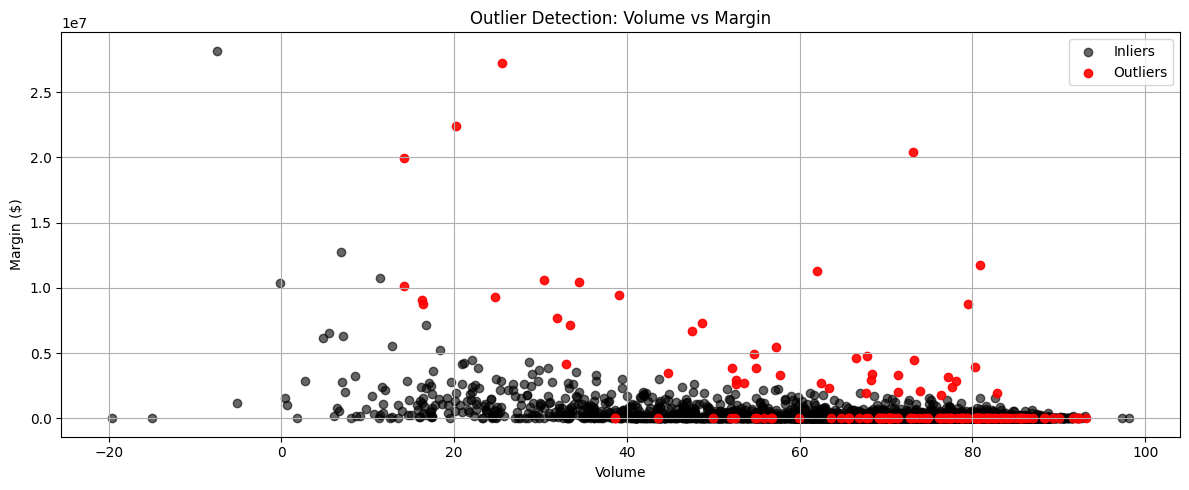

In [87]:
# Plot original data, color by outlier status
plt.figure(figsize=(12, 5))
plt.scatter(
    df["c_yearly_margin_per_liter"][~df["is_outlier"]],
    df["c_yearly_network_volumen"][~df["is_outlier"]],
    color="black",
    label="Inliers",
    alpha=0.6,
)
plt.scatter(
    df["c_yearly_margin_per_liter"][df["is_outlier"]],
    df["c_yearly_network_volumen"][df["is_outlier"]],
    color="red",
    label="Outliers",
    alpha=0.9,
)
plt.xlabel("Volume")
plt.ylabel("Margin ($)")
plt.title("Outlier Detection: Volume vs Margin")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

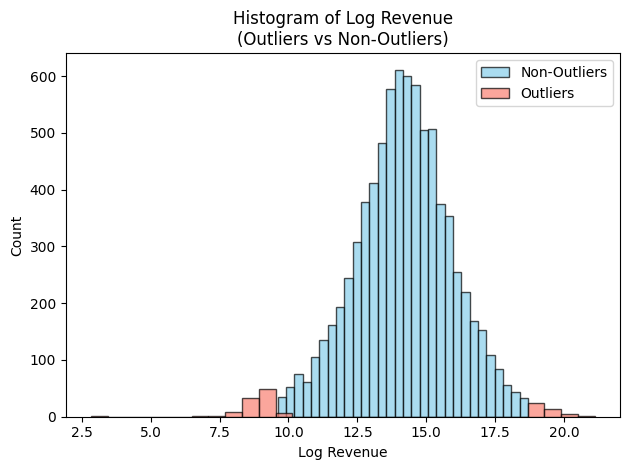

In [67]:
# Separate the data
non_outliers = df[df["is_outlier"] == False]["log_revenue"]
outliers = df[df["is_outlier"] == True]["log_revenue"]

# Create histogram
bins = 30  # you can change the number of bins

plt.hist(
    non_outliers,
    bins=bins,
    alpha=0.7,
    label="Non-Outliers",
    color="skyblue",
    edgecolor="black",
)
plt.hist(
    outliers, bins=bins, alpha=0.7, label="Outliers", color="salmon", edgecolor="black"
)

# Add labels
plt.xlabel("Log Revenue")
plt.ylabel("Count")
plt.title("Histogram of Log Revenue\n(Outliers vs Non-Outliers)")
plt.legend()
plt.tight_layout()
plt.show()